
## Lab1.1: Análisis exploratorio de datos con PANDAS y NUMPY

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.style.use("dark_background")

In [6]:
data = sns.load_dataset("penguins").dropna().values
df = pd.DataFrame(
    data,
    columns=[
        "especie",
        "isla",
        "longitud_pico (mm)",
        "profundidad_pico (mm)",
        "longitud_aleta (mm)",
        "masa_corporal (g)",
        "genero",
    ],
)

df[:5]

,especie,isla,longitud_pico (mm),profundidad_pico (mm),longitud_aleta (mm),masa_corporal (g),genero
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


Esto cargará un dataframe (df), usando la librería seaborn, con algunas características morfológicas y geográficas de diferentes especies de pingüinos. Las columnas contienen los siguientes datos:

```
[especie, isla, longitud del pico, profundidad del pico, longitud de la aleta, masa corporal, genero]
```

https://github.com/allisonhorst/palmerpenguins/blob/main/man/figures/lter_penguins.png

![see](https://github.com/allisonhorst/palmerpenguins/blob/main/man/figures/lter_penguins.png?raw=true)

## Laboratorio 1

1.   ¿Cuáles son las profundidades del pico máxima y mínima de los pinguinos de la isla Torgersen?

2.    ¿De qué isla, especie y género es el pingüino con la mayor masa corporal?
       **Ayuda:** utilice la función `argmax()`

3.   ¿Cuál es la masa corporal media de los pinguinos macho que no son de la especie Gentoo?

4.   Grafique la distribución de la longitud del pico. Añada el valor medio y la desviación estándar en el título de la figura. **Ayuda:** utilice la funcion `hist()`

5.   ¿Cuáles son las islas y especies presentes en el conjunto de datos? ¿Con qué frecuencia aparecen? Grafique la distribución de la masa corporal para los pingüinos.




  



## <span style="color:green; font-size: 30px">Solución<span>

### <span style="color:#7EED6D; font-size:20px">Analisis Inicial<span>

In [206]:
df.head(10)

,especie,isla,longitud_pico (mm),profundidad_pico (mm),longitud_aleta (mm),masa_corporal (g),genero
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
5,Adelie,Torgersen,38.9,17.8,181.0,3625.0,Female
6,Adelie,Torgersen,39.2,19.6,195.0,4675.0,Male
7,Adelie,Torgersen,41.1,17.6,182.0,3200.0,Female
8,Adelie,Torgersen,38.6,21.2,191.0,3800.0,Male
9,Adelie,Torgersen,34.6,21.1,198.0,4400.0,Male


In [207]:
df.shape

(333, 7)

In [208]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 333 entries, 0 to 332
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   especie                333 non-null    str   
 1   isla                   333 non-null    str   
 2   longitud_pico (mm)     333 non-null    object
 3   profundidad_pico (mm)  333 non-null    object
 4   longitud_aleta (mm)    333 non-null    object
 5   masa_corporal (g)      333 non-null    object
 6   genero                 333 non-null    str   
dtypes: object(4), str(3)
memory usage: 18.3+ KB


In [209]:
df["longitud_pico (mm)"] = df["longitud_pico (mm)"].astype(float)
df["profundidad_pico (mm)"] = df["profundidad_pico (mm)"].astype(float)
df["longitud_aleta (mm)"] = df["longitud_aleta (mm)"].astype(float)
df["masa_corporal (g)"] = df["masa_corporal (g)"].astype(float)

In [210]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 333 entries, 0 to 332
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   especie                333 non-null    str    
 1   isla                   333 non-null    str    
 2   longitud_pico (mm)     333 non-null    float64
 3   profundidad_pico (mm)  333 non-null    float64
 4   longitud_aleta (mm)    333 non-null    float64
 5   masa_corporal (g)      333 non-null    float64
 6   genero                 333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.3 KB


In [211]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
longitud_pico (mm),333.0,43.992793,5.468668,32.1,39.5,44.5,48.6,59.6
profundidad_pico (mm),333.0,17.164865,1.969235,13.1,15.6,17.3,18.7,21.5
longitud_aleta (mm),333.0,200.966967,14.015765,172.0,190.0,197.0,213.0,231.0
masa_corporal (g),333.0,4207.057057,805.215802,2700.0,3550.0,4050.0,4775.0,6300.0


In [38]:
df.describe(include=str).T

,count,unique,top,freq
especie,333,3,Adelie,146
isla,333,3,Biscoe,163
genero,333,2,Male,168


### <span style="color:#7EED6D; font-size:20px">1.   ¿Cuáles son las profundidades del pico máxima y mínima de los pinguinos de la isla Torgersen?<span>

In [39]:
df_Torgersen = df[df["isla"] == "Torgersen"]
df_Torgersen.head()

,especie,isla,longitud_pico (mm),profundidad_pico (mm),longitud_aleta (mm),masa_corporal (g),genero
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


In [ ]:
df_Torgersen[
    df_Torgersen["profundidad_pico (mm)"] == df_Torgersen["profundidad_pico (mm)"].max()
]

,especie,isla,longitud_pico (mm),profundidad_pico (mm),longitud_aleta (mm),masa_corporal (g),genero
14,Adelie,Torgersen,46.0,21.5,194.0,4200.0,Male


In [ ]:
df_Torgersen[
    df_Torgersen["profundidad_pico (mm)"] == df_Torgersen["profundidad_pico (mm)"].min()
]

,especie,isla,longitud_pico (mm),profundidad_pico (mm),longitud_aleta (mm),masa_corporal (g),genero
118,Adelie,Torgersen,35.2,15.9,186.0,3050.0,Female


In [ ]:
max_profundidad_pico = df_Torgersen["profundidad_pico (mm)"].max()
min_profundidad_pico = df_Torgersen["profundidad_pico (mm)"].min()
print(
    f"La profundidad maxima de los picos de los pinguinos de la isla Torgersen es: {max_profundidad_pico} y la profundidad minima es: {min_profundidad_pico}"
)

La profundidad maxima de los picos de los pinguinos de la isla Torgersen es: 21.5 y la profundidad minima es: 15.9


BIEN...

### <span style="color:#7EED6D; font-size:20px">2.    ¿De qué isla, especie y género es el pingüino con la mayor masa corporal? **Ayuda:** utilice la función `argmax()`<span>

In [55]:
indice = np.argmax(df["masa_corporal (g)"])
df.iloc[[indice]]

,especie,isla,longitud_pico (mm),profundidad_pico (mm),longitud_aleta (mm),masa_corporal (g),genero
231,Gentoo,Biscoe,49.2,15.2,221.0,6300.0,Male


El pinguino con la mayor masa corporal es de la isla Biscoe, es un macho y es de la especia Gentoo

### <span style="color:#7EED6D; font-size:20px">3.   ¿Cuál es la masa corporal media de los pinguinos macho que no son de la especie Gentoo?<span>

In [ ]:
df_sin_gentoo = df[df["especie"] != "Gentoo"]
masa_media = df_sin_gentoo["masa_corporal (g)"].mean()
print(
    f"La masa corporal media de los pinguinos que no son de la especia Gentoo es: {masa_media:0.2f}"
)

La masa corporal media de los pinguinos que no son de la especia Gentoo es: 3714.72


ESTÁ MAL... ES 4010.3 G

### <span style="color:#7EED6D; font-size:20px">4.   Grafique la distribución de la longitud del pico. Añada el valor medio y la desviación estándar en el título de la figura. **Ayuda:** utilice la funcion `hist()`
<span>

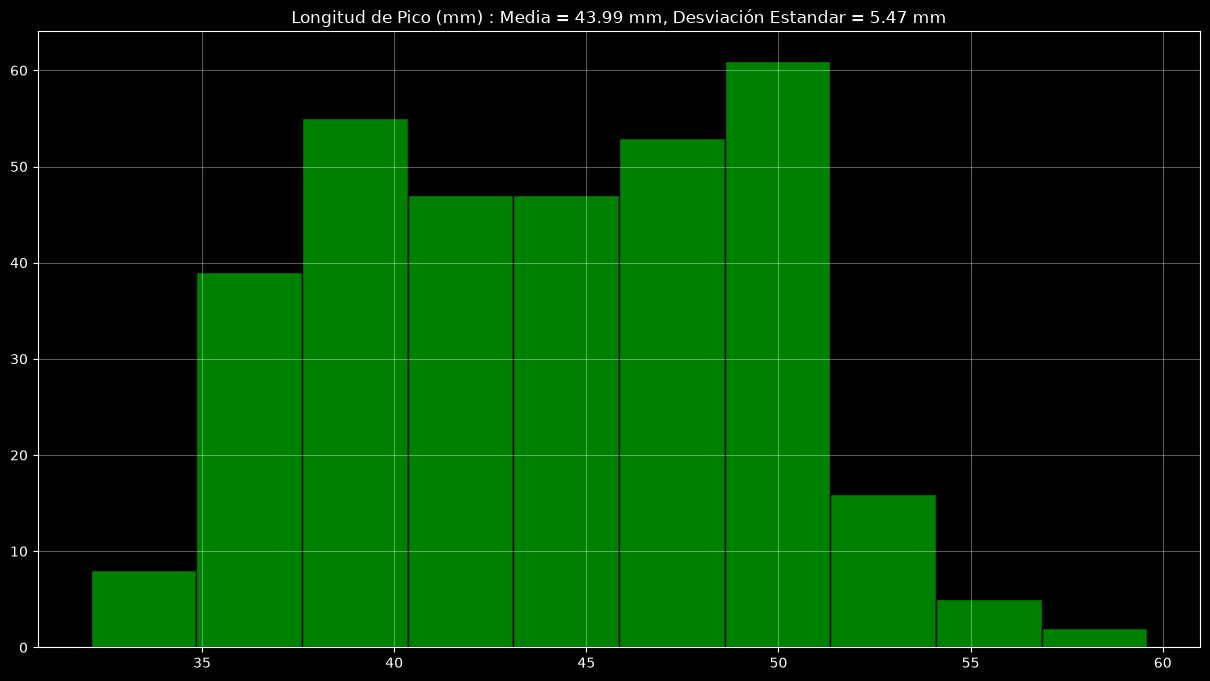

In [ ]:
df["longitud_pico (mm)"].hist(edgecolor="black", color="green", figsize=(15, 8))
plt.title(
    f"Longitud de Pico (mm) : Media = {df['longitud_pico (mm)'].mean():.2f} mm, Desviación Estandar = {df['longitud_pico (mm)'].std():.2f} mm"
)
plt.grid(alpha=0.35)
plt.show()

### <span style="color:#7EED6D; font-size:20px">5.   ¿Cuáles son las islas y especies presentes en el conjunto de datos? ¿Con qué frecuencia aparecen? Grafique la distribución de la masa corporal para los pingüinos.<span>

In [213]:
data_especie = df["especie"].value_counts().values
columna_especie = df["especie"].unique()
especies = pd.Series(data=data_especie, index=columna_especie)
especies

Adelie       146
Chinstrap    119
Gentoo        68
dtype: int64

La distribucion de masa corporal para cada especie de pinguino

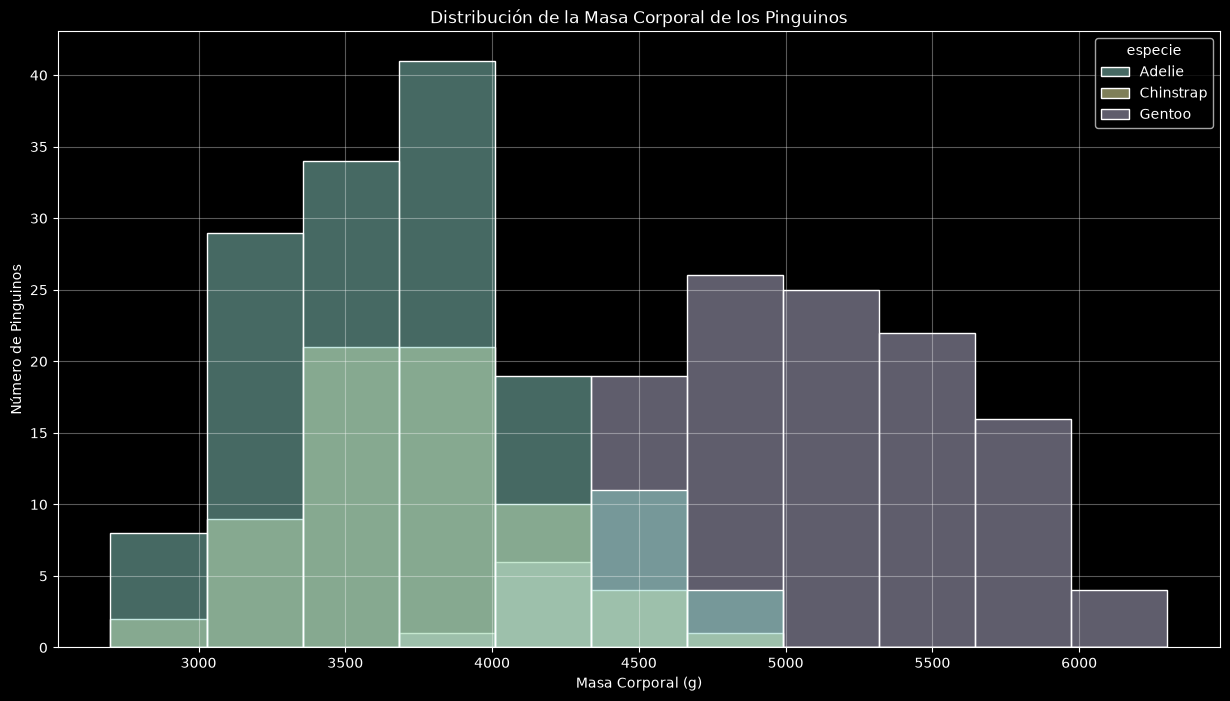

In [17]:
fig, ax = plt.subplots(figsize=(15, 8))
sns.histplot(data=df, x="masa_corporal (g)", color="pink", ax=ax, hue="especie")
plt.title("Distribución de la Masa Corporal de los Pinguinos")
plt.grid(True, alpha=0.35)
plt.xlabel("Masa Corporal (g)")
plt.ylabel("Número de Pinguinos")
plt.show()

La distribucion de masa corporal para todos los pinguinos

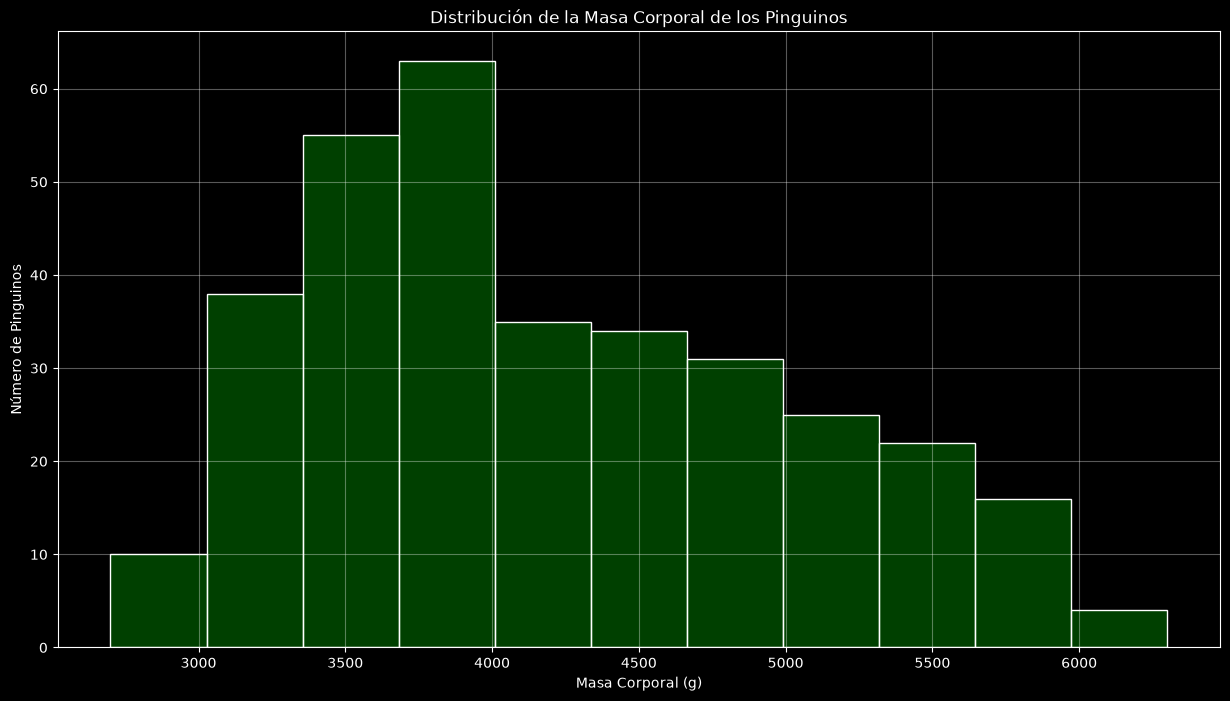

In [ ]:
fig, ax = plt.subplots(figsize=(15, 8))
sns.histplot(data=df["masa_corporal (g)"], color="green", ax=ax)
plt.title("Distribución de la Masa Corporal de los Pinguinos")
plt.grid(True, alpha=0.35)
plt.xlabel("Masa Corporal (g)")
plt.ylabel("Número de Pinguinos")
plt.show()

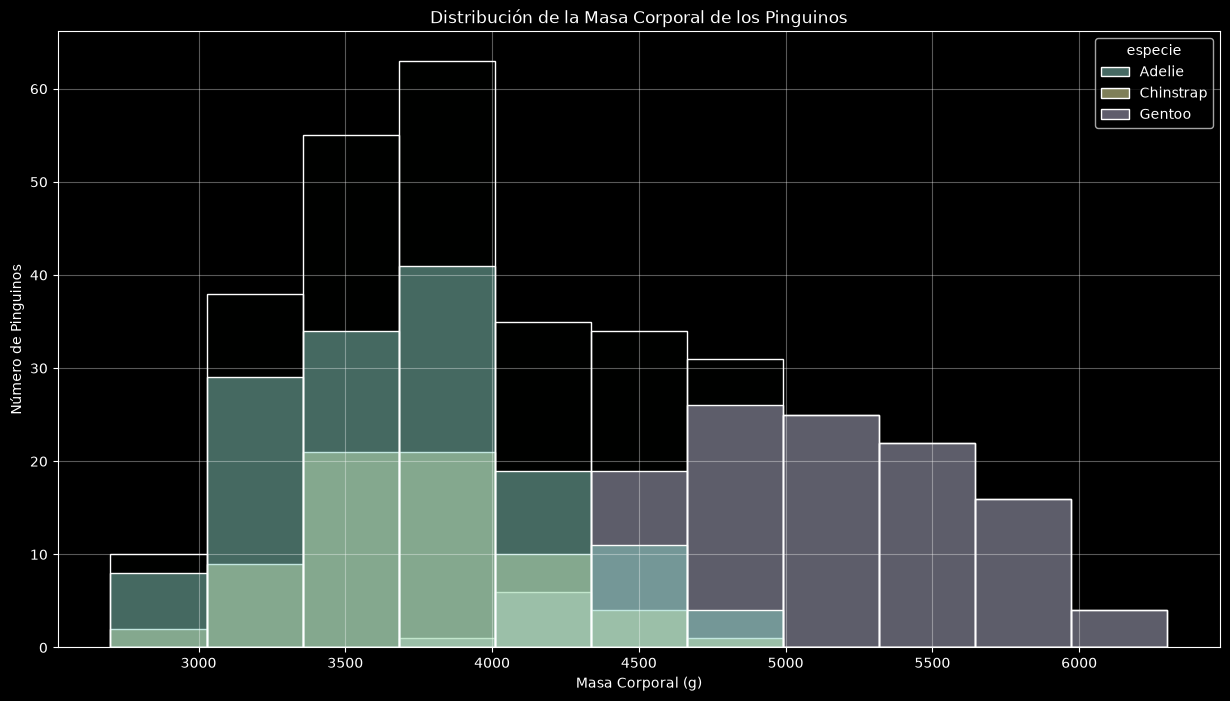

In [24]:
fig, ax = plt.subplots(figsize=(15, 8))
sns.histplot(data=df, x="masa_corporal (g)", color="pink", ax=ax, hue="especie")
sns.histplot(data=df["masa_corporal (g)"], color="green", ax=ax , alpha = 0.01)
plt.title("Distribución de la Masa Corporal de los Pinguinos")
plt.grid(True, alpha=0.35)
plt.xlabel("Masa Corporal (g)")
plt.ylabel("Número de Pinguinos")
plt.show()

In [25]:
data_isla = df["isla"].value_counts().values
columna_isla = df["isla"].unique()
isla = pd.Series(data=data_isla, index=columna_isla)
isla

Torgersen    163
Biscoe       123
Dream         47
dtype: int64

REVISAR EL 3. 
MUY BIEN. NOTA 4.8
